# デモ分析＿田中桜子
### 下準備

In [2]:
import pandas as pd

weekly_df = pd.read_csv("onboarding_demo_data/demo_weekly_data.csv")

print(weekly_df)

        Unnamed: 0                 user_id        WEEK    price  quantity  \
0                0   T_3172160315204673327  2024-11-28   4912.0      15.0   
1                1   T_2248139076213326705  2024-11-28      0.0       0.0   
2                2   T_5448941342309646857  2024-11-28   6569.0       9.0   
3                3   T_1897433679415054908  2024-11-28  10419.0       6.0   
4                4   T_4607605241549732400  2024-11-28  11293.0      12.0   
...            ...                     ...         ...      ...       ...   
842694      842694  T_14028156525552909614  2022-11-10   6729.0      13.0   
842695      842695   T_3572762999312094593  2022-11-10   4767.0      12.0   
842696      842696  T_16061538040795971187  2022-11-10      0.0       0.0   
842697      842697   T_3010068684522825960  2022-11-10   6087.0       3.0   
842698      842698  T_10807451140741212136  2022-11-10   7847.0      15.0   

        price_per_unit  
0           327.466667  
1             0.000000  


In [3]:
user_df = pd.read_csv("onboarding_demo_data/demo_user_master.csv")
user_df["user_id"] = "T_" + user_df["user_id"].astype(str)
print(user_df)

                      user_id  avg_days_to_next_purchase  \
0           T_382396530093826                  22.166667   
1           T_702123357606349                        NaN   
2          T_1034173341858962                   8.166667   
3          T_2406074538230035                  35.000000   
4          T_2707839637451658                        NaN   
...                       ...                        ...   
55201  T_18445155889209774351                  11.666667   
55202  T_18445691103045604664                   7.000000   
55203  T_18446164387732449311                  10.000000   
55204  T_18446317442404922081                   8.166667   
55205  T_18446318488994809340                        NaN   

       price_mean_per_order  quantity_mean_per_order  days_to_treatment  
0               4689.857143                15.000000                684  
1               5118.000000                18.000000                691  
2               5952.210526                18.000000     

In [4]:
import json

with open("onboarding_demo_data/treatment_and_controll_dict.json", "r") as file:
    tc_df = json.load(file)

print(tc_df)

{'treatment': ['T_10020687524851798301', 'T_10022411737712421633', 'T_10022860563193664494', 'T_10023318969947196591', 'T_10025787604583481250', 'T_10042266184079763583', 'T_10046721007037588375', 'T_10065337672046237922', 'T_1006701098052296634', 'T_10068026945539634986', 'T_10092599843510703225', 'T_10097469101873257702', 'T_10104320508100445347', 'T_10108666273855923076', 'T_10110515759200525124', 'T_10117719519707918121', 'T_10131978319774096108', 'T_10132781584966038066', 'T_10144641418498146667', 'T_10152752398955892070', 'T_10165671297601544638', 'T_1016621638832926107', 'T_10170377482894534881', 'T_10177799523526024835', 'T_10178011250987227549', 'T_10181503497211025586', 'T_10192786470921807139', 'T_10204139271824302325', 'T_1022598382477057886', 'T_1026426388085887889', 'T_10291733895053806484', 'T_10294350364036701044', 'T_10297879270983650266', 'T_10298982996529191547', 'T_10303351216214017865', 'T_10306703549018589982', 'T_10316107020358509321', 'T_10323918084653127933', '

In [5]:
print(len(tc_df["treatment"]))

1500


In [6]:
treatment_ids = tc_df["treatment"]
print(treatment_ids)

['T_10020687524851798301', 'T_10022411737712421633', 'T_10022860563193664494', 'T_10023318969947196591', 'T_10025787604583481250', 'T_10042266184079763583', 'T_10046721007037588375', 'T_10065337672046237922', 'T_1006701098052296634', 'T_10068026945539634986', 'T_10092599843510703225', 'T_10097469101873257702', 'T_10104320508100445347', 'T_10108666273855923076', 'T_10110515759200525124', 'T_10117719519707918121', 'T_10131978319774096108', 'T_10132781584966038066', 'T_10144641418498146667', 'T_10152752398955892070', 'T_10165671297601544638', 'T_1016621638832926107', 'T_10170377482894534881', 'T_10177799523526024835', 'T_10178011250987227549', 'T_10181503497211025586', 'T_10192786470921807139', 'T_10204139271824302325', 'T_1022598382477057886', 'T_1026426388085887889', 'T_10291733895053806484', 'T_10294350364036701044', 'T_10297879270983650266', 'T_10298982996529191547', 'T_10303351216214017865', 'T_10306703549018589982', 'T_10316107020358509321', 'T_10323918084653127933', 'T_103303814483

In [7]:
print(len(treatment_ids))

1500


In [8]:
control_ids = tc_df["control"]

In [66]:
target_ids = treatment_ids + control_ids
filtered_weekly_df = weekly_df[weekly_df["user_id"].isin(target_ids)].copy()

filtered dataframe for weekly data and user master data

In [10]:
treatment_weekly_df = weekly_df[weekly_df["user_id"].isin(treatment_ids)].copy()
control_weekly_df = weekly_df[weekly_df["user_id"].isin(control_ids)].copy()

In [11]:
treatment_user_df = user_df[user_df["user_id"].isin(treatment_ids)].copy()
control_user_df = user_df[user_df["user_id"].isin(control_ids)].copy()

setting up the iterato environment

In [12]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import iterato_run.api_config as api_config
from iterato_run import IteratoOptimizer, IteratoPredictor, PredictionConfig
from iterato_run.visualization import calculate_all_uplifts, create_lift_plot

In [13]:
with open("secret.json", "r", encoding="utf-8") as f:
    secret = json.load(f)

api_config.configure(
    api_key_id=secret["ITERATO_API_KEY_ID"],
    api_secret=secret["ITERATO_API_SECRET"],
)
optimizer = IteratoOptimizer(verbose=True)

## プラセボ分析

random assignment of placebo sample

In [14]:
import random

random.seed(42)

placebo_treatment = random.sample(control_ids, 1000)
placebo_control = [x for x in control_ids if x not in placebo_treatment]


### 過学習上等マッチング

In [15]:
base_config_max = {
    "entity_col": "user_id",
    "time_col": "WEEK",
    "outcomes": ["price", "quantity", "price_per_unit"],
    "topk": 7500,
    "max_entity_weight_percent": 50,
    "loss_type": "bias_ratio_rmse",

    # 期間設定
    "matching_start": "2024-05-02",   # マッチング期間（施策前）開始
    "matching_end":   "2024-09-26",   # マッチング期間 終了
    "treatment_start": "2024-10-03",  # 施策（評価）期間 開始
    "eval_end":        "2024-11-28",  # 施策（評価）期間 終了
}

In [16]:
result_max = optimizer.run(
    dataset=control_weekly_df,
    treated_entities=placebo_treatment,
    control_entities=placebo_control,
    config=base_config_max,
    verbose = True
)

🚀 Submitting run job...
  Dataset filtered: 704,006 → 232,500 rows (67.0% reduction)
  Job ID: fe4694af-c6e8-401e-8858-bc3ff0d6e1b3
⏳ Waiting for job fe4694af-c6e8-401e-8858-bc3ff0d6e1b3 to complete (checking every 10s)...


KeyboardInterrupt: 

In [ ]:
config = PredictionConfig.from_hyperparameters(result_max['final_hyperparameters'])
predictor = IteratoPredictor(config)
result_predict = predictor.predict(
    df=control_weekly_df,
    final_weight=result_max['final_weight'],
    standardization_info=result_max['standardization_info'],
)
df_pred = result_predict.predictions

Prediction | Preprocessing data: started
Prediction | Loading standardization info
Applying standardization: 7500 entities
Applying standardization: completed
Prediction | Computing predictions: started (entities=1000)
Prediction | Processing: 1000/1000 entities

=== Prediction Statistics ===
Total entities with weights: 1000
Successfully predicted: 1000
Skipped (not in data): 0
Skipped (no controls): 0
Skipped (controls not in data): 0
Prediction | Computing predictions: completed (108000 rows)


In [ ]:
df_uplifts = calculate_all_uplifts(
    df_predict=df_pred,
    outcomes=["price", "quantity", "price_per_unit"],
    treatment_start='2024-10-03',
    eval_end='2024-11-28',
    entity_col=config.entity_col,
    time_col=config.time_col,
)

In [ ]:
matching_dates = pd.date_range(start='2024-05-02', end='2024-11-28', freq='W')
for outcome in ["price", "quantity", "price_per_unit"]:
    create_lift_plot(
        df_predict=df_pred,
        outcome=outcome,
        start='2024-05-02', end='2024-11-28',
        matching_dates=matching_dates,
        treatment_start='2024-10-03',
        entity_col=config.entity_col, time_col=config.time_col,
        show_plot=True,
    )

### Grid search attempt 1 (ran too long, don't use)

In [ ]:
# param_grid = {
    "topk": [100, 700, 1500],
    "max_entity_weight_percent": [5,10],
    "loss_type": ["bias_ratio_rmse","rmse"]
}

In [ ]:
# search_result = optimizer.search_parameters(
    dataset=control_weekly_df,
    treated_entities=placebo_treatment,
    control_entities=placebo_control,
    base_config=base_config,
    param_grid=param_grid,
    verbose=True,
)

In [ ]:
# result = optimizer.run(
    dataset=control_weekly_df,
    treated_entities=placebo_treatment,   # 本番の T 群
    control_entities=placebo_control,     # 本番の C 群
    search_result=search_result,
)

In [ ]:
# config = PredictionConfig.from_hyperparameters(result['final_hyperparameters'])
# predictor = IteratoPredictor(config)
# result_predict = predictor.predict(
#     df=control_weekly_df,
#     final_weight=result['final_weight'],
#     standardization_info=result['standardization_info'],
# )
# df_pred = result_predict.predictions

# df_uplifts = calculate_all_uplifts(
#     df_predict=df_pred,
#     outcomes=["price", "quantity", "price_per_unit"],
#     treatment_start='2024-10-03',
#     eval_end='2024-11-28',
#     entity_col=config.entity_col,
#     time_col=config.time_col,
# )

# matching_dates = pd.date_range(start='2024-05-02', end='2024-11-28', freq='W')
# for outcome in ["price", "quantity", "price_per_unit"]:
#     create_lift_plot(
#         df_predict=df_pred,
#         outcome=outcome,
#         start='2024-05-02', end='2024-11-28',
#         matching_dates=matching_dates,
#         treatment_start='2024-10-03',
#         entity_col=config.entity_col, time_col=config.time_col,
#         show_plot=True,
#     )


### Grid search attempt 2:
result: topk = 50, max_entity_weight_percent = 20, loss_type = trend_bias_mae

In [67]:
base_config = {
    "outcomes": ["price", "quantity", "price_per_unit"],
    "entity_col": "user_id",
    "time_col": "WEEK",
    "matching_start": "2024-05-02",   
    "matching_end":   "2024-09-26",  
    "treatment_start": "2024-10-03", 
    "eval_end":        "2024-11-28", 

    # grid search後に追加、もう一度探索回さなくて良いように
    "topk": 50,
    "max_entity_weight_percent": 20,
    "loss_type": "trend_bias_mae",
}

In [69]:
param_grid2 = {
    "topk": [50,100,200],
    "max_entity_weight_percent": [10,20],
    "loss_type": ["bias_ratio_rmse","trend_bias_mae"]
}

In [68]:
##　走り直すと時間がかかるので、結果を記録し、サーチ部分は次から回らないようにする。

# search_result = optimizer.search_parameters(
#     dataset=control_weekly_df,
#     treated_entities=placebo_treatment,
#     control_entities=placebo_control,
#     base_config=base_config,
#     param_grid=param_grid2,
#     verbose=True,
# )

In [ ]:
result = optimizer.run(
    dataset=control_weekly_df,
    treated_entities=placebo_treatment,  
    control_entities=placebo_control,   
    config = base_config
)

🚀 Submitting run job...
  Dataset filtered: 704,006 → 232,500 rows (67.0% reduction)
  Job ID: 948627da-bb23-477b-8fd7-a1146c32e2c4
⏳ Waiting for job 948627da-bb23-477b-8fd7-a1146c32e2c4 to complete (checking every 10s)...
  Status: queued
  Status: running
  Status: running
  Status: running
  Status: running
  Status: running
  Status: running
  Status: running
  Status: running
  Status: running
  Status: succeeded
✓ Job completed successfully!
📥 Downloading result...
  Result downloaded: 4 keys
✓ Run completed successfully


### Final Placebo Graphs

In [19]:
config = PredictionConfig.from_hyperparameters(result['final_hyperparameters'])
predictor = IteratoPredictor(config)
result_predict = predictor.predict(
    df=control_weekly_df,
    final_weight=result['final_weight'],
    standardization_info=result['standardization_info'],
)
df_pred_placebo = result_predict.predictions

df_uplifts = calculate_all_uplifts(
    df_predict=df_pred_placebo,
    outcomes=["price", "quantity", "price_per_unit"],
    treatment_start='2024-10-03',
    eval_end='2024-11-28',
    entity_col=config.entity_col,
    time_col=config.time_col,
)

matching_dates = pd.date_range(start='2024-05-02', end='2024-11-28', freq='W')
for outcome in ["price", "quantity", "price_per_unit"]:
    create_lift_plot(
        df_predict=df_pred_placebo,
        outcome=outcome,
        start='2024-05-02', end='2024-11-28',
        matching_dates=matching_dates,
        treatment_start='2024-10-03',
        entity_col=config.entity_col, time_col=config.time_col,
        show_plot=True,
    )

Prediction | Preprocessing data: started
Prediction | Loading standardization info
Applying standardization: 7500 entities
Applying standardization: completed
Prediction | Computing predictions: started (entities=1000)
Prediction | Processing: 1000/1000 entities

=== Prediction Statistics ===
Total entities with weights: 1000
Successfully predicted: 1000
Skipped (not in data): 0
Skipped (no controls): 0
Skipped (controls not in data): 0
Prediction | Computing predictions: completed (108000 rows)


## 本分析

In [20]:
config_dict = {
    "entity_col": "user_id",
    "time_col": "WEEK",
    "outcomes": ["price", "quantity", "price_per_unit"],
    "topk": 50,
    "max_entity_weight_percent": 20,
    "loss_type": "trend_bias_mae",

    # 期間設定
    "matching_start": "2024-05-02",   # マッチング期間（施策前）開始
    "matching_end":   "2024-09-26",   # マッチング期間 終了
    "treatment_start": "2024-10-03",  # 施策（評価）期間 開始
    "eval_end":        "2024-11-28",  # 施策（評価）期間 終了
}

In [21]:
result = optimizer.run(
    dataset=filtered_weekly_df,
    treated_entities=treatment_ids,
    control_entities=control_ids,
    config=config_dict,
)

🚀 Submitting run job...
  Dataset filtered: 842,699 → 279,000 rows (66.9% reduction)
  Job ID: 2ed93586-2751-4328-8230-d1a8e07d00bf
⏳ Waiting for job 2ed93586-2751-4328-8230-d1a8e07d00bf to complete (checking every 10s)...
  Status: running
  Status: running
  Status: running
  Status: running
  Status: running
  Status: running
  Status: running
  Status: running
  Status: running
  Status: running
  Status: running
  Status: succeeded
✓ Job completed successfully!
📥 Downloading result...
  Result downloaded: 4 keys
✓ Run completed successfully


In [22]:
config = PredictionConfig.from_hyperparameters(result['final_hyperparameters'])
predictor = IteratoPredictor(config)
result_predict = predictor.predict(
    df=filtered_weekly_df,
    final_weight=result['final_weight'],
    standardization_info=result['standardization_info'],
)
df_pred = result_predict.predictions

df_uplifts = calculate_all_uplifts(
    df_predict=df_pred,
    outcomes=["price", "quantity", "price_per_unit"],
    treatment_start='2024-10-03',
    eval_end='2024-11-28',
    entity_col=config.entity_col,
    time_col=config.time_col,
)

matching_dates = pd.date_range(start='2024-05-02', end='2024-11-28', freq='W')
for outcome in ["price", "quantity", "price_per_unit"]:
    create_lift_plot(
        df_predict=df_pred,
        outcome=outcome,
        start='2024-05-02', end='2024-11-28',
        matching_dates=matching_dates,
        treatment_start='2024-10-03',
        entity_col=config.entity_col, time_col=config.time_col,
        show_plot=True,
    )

Prediction | Preprocessing data: started
Prediction | Loading standardization info
Applying standardization: 9000 entities
Applying standardization: completed
Prediction | Computing predictions: started (entities=1500)
Prediction | Processing: 1500/1500 entities

=== Prediction Statistics ===
Total entities with weights: 1500
Successfully predicted: 1500
Skipped (not in data): 0
Skipped (no controls): 0
Skipped (controls not in data): 0
Prediction | Computing predictions: completed (162000 rows)


Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[40]	valid's rmse: 32.1109
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[34]	valid's rmse: 32.1649
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	valid's rmse: 32.4041
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[63]	valid's rmse: 31.6762
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[17]	valid's rmse: 31.7157
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	valid's rmse: 32.3659
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[10]	valid's rmse: 32.2841
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	valid's rmse: 32.4686
Training until vali

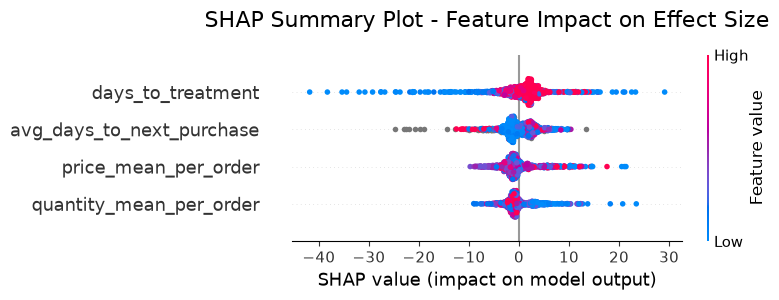

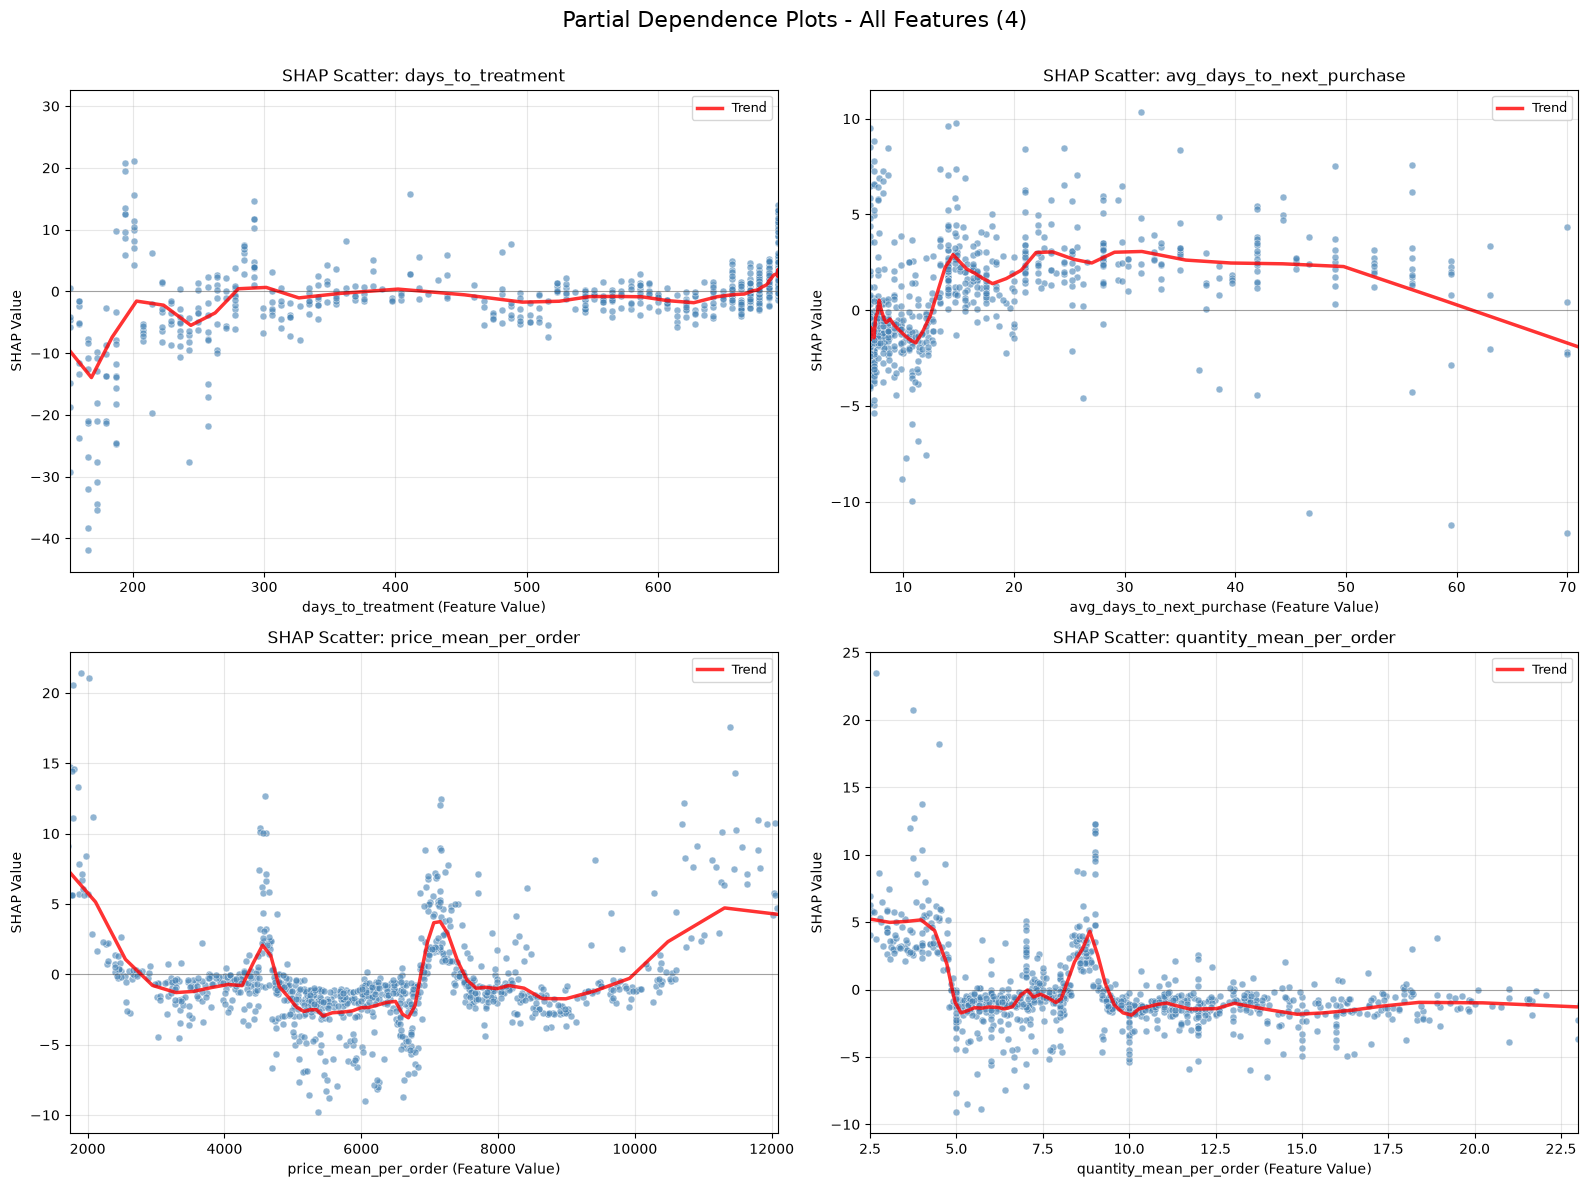

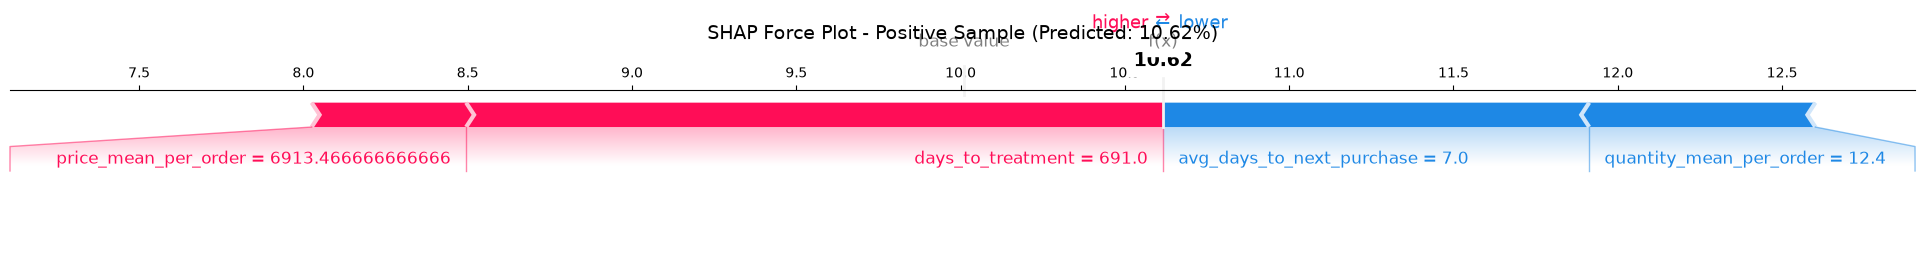

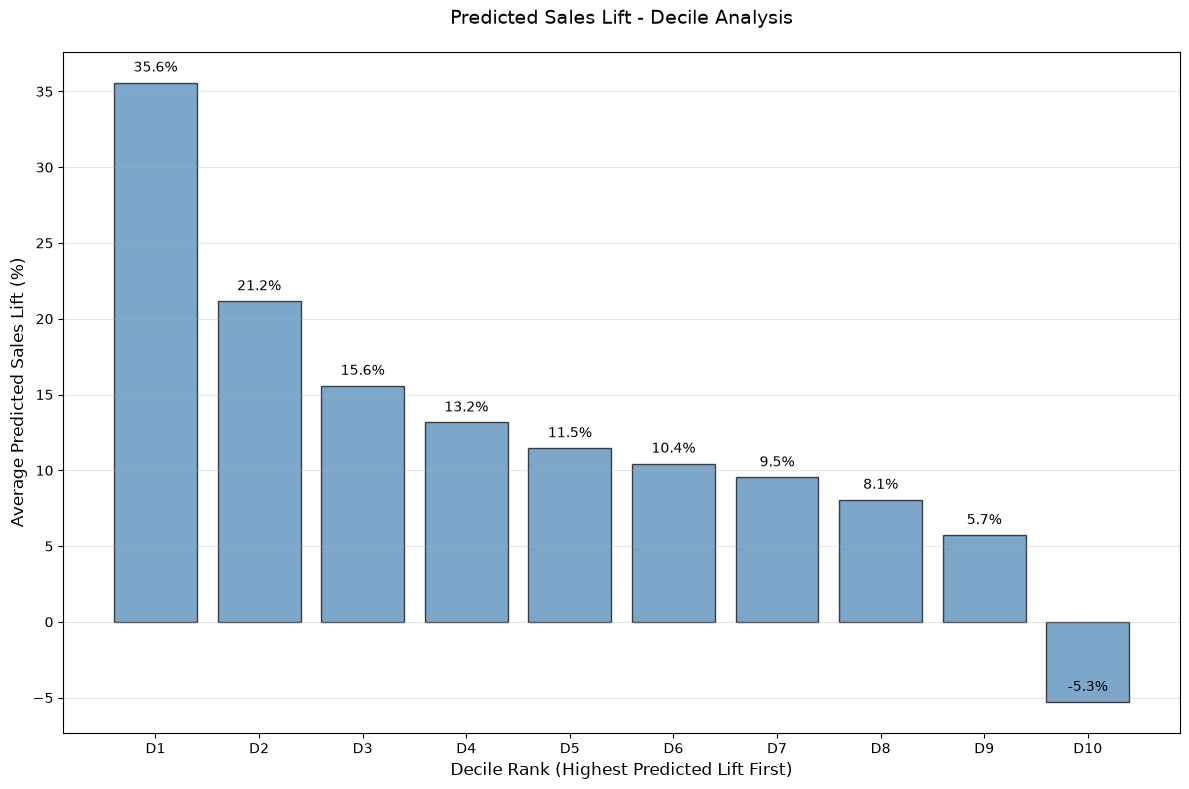

In [23]:
from iterato_run.kpi_analysis import create_kpi_analysis

# 固定期間モード
result = create_kpi_analysis(
    predictions_df=df_pred,
    feature_table=user_df,
    outcome="quantity",
    entity_col="user_id",
    time_col="WEEK",
    treatment_start="2024-10-03",
    plot_types=["summary", "scatter", "force", "decile"],
    is_search_params=True,
    n_trials=30,
    placebo_predictions=None,
)

KPI analysis for `price`

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	valid's rmse: 77.1234
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	valid's rmse: 77.4899
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	valid's rmse: 76.6299
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	valid's rmse: 77.3502
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[4]	valid's rmse: 75.6704
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[10]	valid's rmse: 76.2641
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[6]	valid's rmse: 75.3221
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	valid's rmse: 76.4167
Training until validati

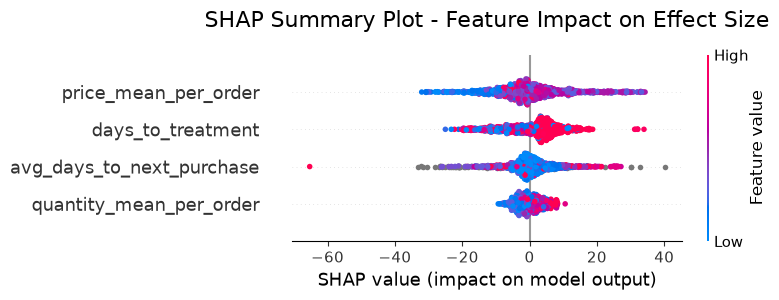

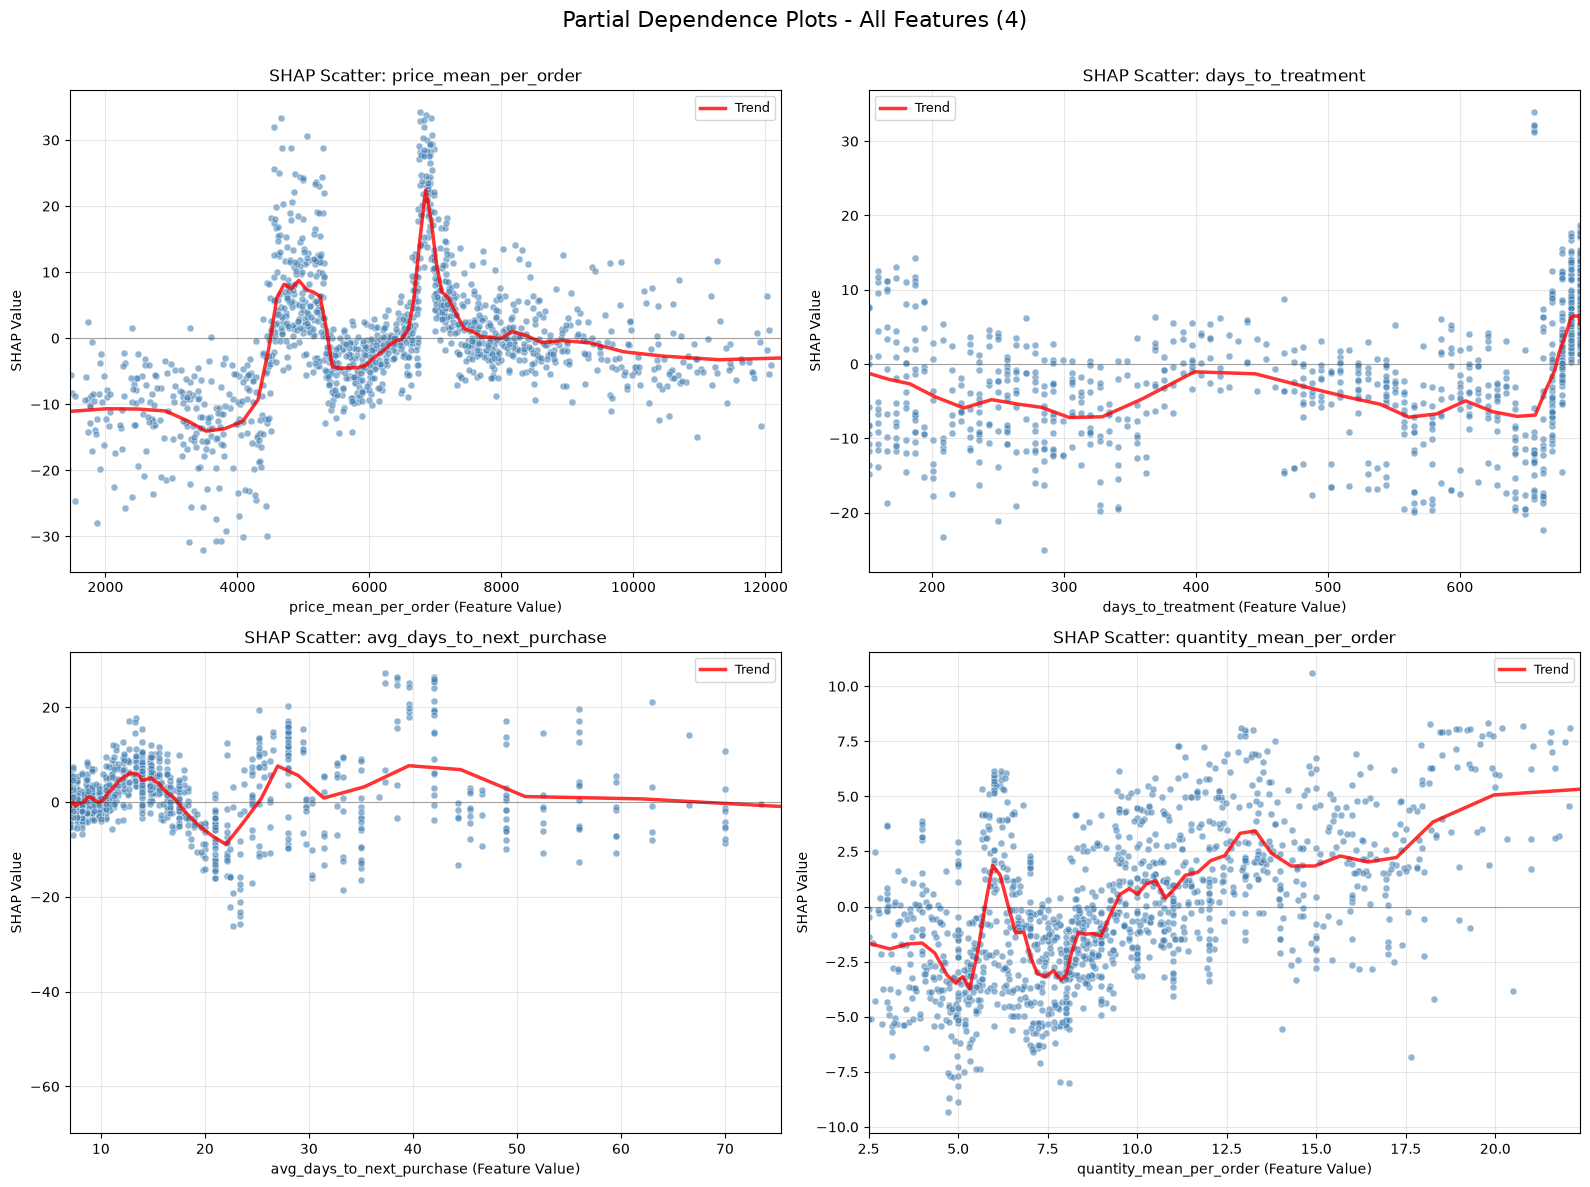

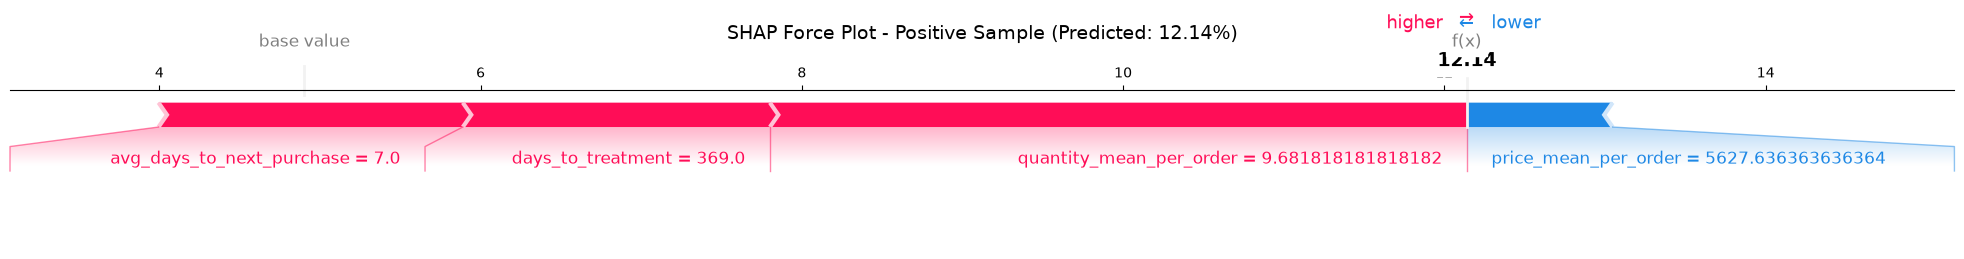

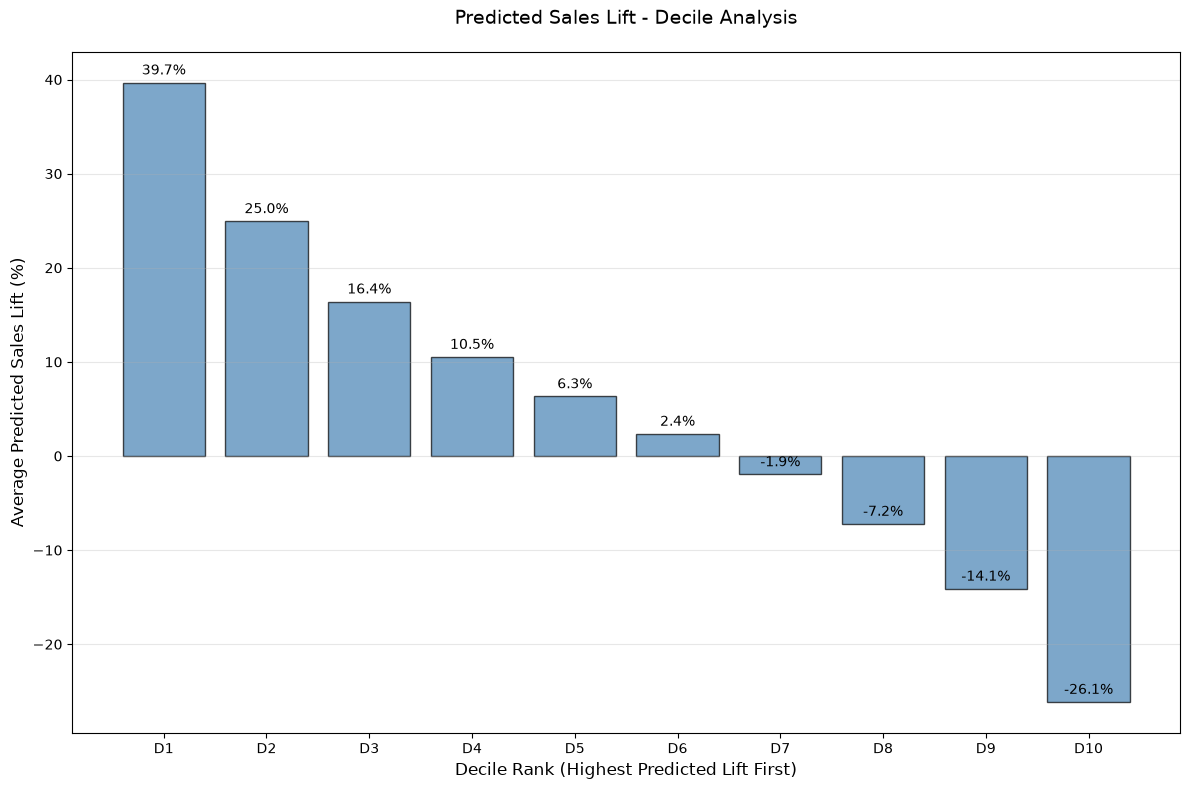

In [32]:
feature_columns = [
    "price_mean_per_order",
    "avg_days_to_next_purchase",
    "quantity_mean_per_order",
    "days_to_treatment"
]

result2 = create_kpi_analysis(
    predictions_df=df_pred,
    feature_table=user_df,
    outcome="price",
    entity_col="user_id",
    time_col="WEEK",
    treatment_start="2024-10-03",
    plot_types=["summary", "scatter", "force", "decile"],
    is_search_params=True,
    n_trials=30,
    shap_sample_size=5000,
    feature_columns = feature_columns,
    placebo_predictions=None,
)

### 欠測値の処理

In [49]:
# -----------------------------
# Fill avg_days_to_next_purchase
# -----------------------------

user_df_filled = user_df.copy()

target_col = "avg_days_to_next_purchase"
user_col = "user_id"
week_col = "WEEK"
price_col = "price"

before_missing = user_df_filled[target_col].isna().sum()

# Keep rows where a purchase happened
purchases = filtered_weekly_df.loc[
    filtered_weekly_df[price_col].fillna(0) != 0,
    [user_col, week_col]
].copy()

# Convert WEEK to datetime
purchases[week_col] = pd.to_datetime(purchases[week_col])

# One purchase date per user/week, sorted
purchases = (
    purchases.drop_duplicates([user_col, week_col])
             .sort_values([user_col, week_col])
)

# Days between purchases
purchases["days_between_purchases"] = (
    purchases.groupby(user_col)[week_col]
             .diff()
             .dt.days
)

# Average days between purchases per user
avg_days_by_user = (
    purchases.groupby(user_col)["days_between_purchases"]
             .mean()
)

# Fill only missing values
missing_mask = user_df_filled[target_col].isna()

user_df_filled.loc[missing_mask, target_col] = (
    user_df_filled.loc[missing_mask, user_col]
                  .map(avg_days_by_user)
)

after_missing = user_df_filled[target_col].isna().sum()

print("Missing before:", before_missing)
print("Missing after:", after_missing)
print("Values filled:", before_missing - after_missing)

# -----------------------------
# Check remaining missing users
# -----------------------------

purchase_counts = (
    purchases.groupby(user_col)[week_col]
             .count()
)

remaining_missing_users = user_df_filled.loc[
    user_df_filled[target_col].isna(),
    user_col
]

remaining_purchase_counts = (
    remaining_missing_users.map(purchase_counts)
                           .fillna(0)
                           .astype(int)
)

print("\nRemaining missing users by purchase-count:")
print(remaining_purchase_counts.value_counts().sort_index())

problem_users = remaining_missing_users[
    remaining_purchase_counts >= 2
].unique()

print("\nUsers still missing despite 2+ purchases:")
print(problem_users)

Missing before: 5458
Missing after: 4635
Values filled: 823

Remaining missing users by purchase-count:
user_id
0    4605
1      30
Name: count, dtype: int64

Users still missing despite 2+ purchases:
<StringArray>
[]
Length: 0, dtype: str


In [ ]:
# Users whose value was successfully filled
filled_users = user_df_filled.loc[
    user_df["avg_days_to_next_purchase"].isna() &
    user_df_filled["avg_days_to_next_purchase"].notna(),
    "user_id"
].sample(5, random_state=42)

for user_id in filled_users:
    print("=" * 60)
    print(f"User: {user_id}")

    purchases = (
        filtered_weekly_df[
            (filtered_weekly_df["user_id"] == user_id) &
            (filtered_weekly_df["price"] != 0)
        ][["WEEK", "price"]]
        .drop_duplicates()
        .sort_values("WEEK")
    )

    print(purchases)

    dates = pd.to_datetime(purchases["WEEK"])
    gaps = dates.diff().dt.days.dropna()

    print("\nDays between purchases:", gaps.tolist())
    print("Average gap:", gaps.mean())

    filled_value = user_df_filled.loc[
        user_df_filled["user_id"] == user_id,
        "avg_days_to_next_purchase"
    ].iloc[0]

    print("Filled value in user_df_filled:", filled_value)
    print()

User: T_13429782123516247022
              WEEK   price
838629  2022-11-10  2348.0
829184  2022-11-24  4502.0
801319  2022-12-22  4814.0
777399  2023-01-19  4525.0
766418  2023-02-02  4434.0
748164  2023-02-23  4544.0
725624  2023-03-16  4252.0
707924  2023-04-06  4334.0
609244  2023-07-13  4053.0
558041  2023-08-31  4091.0
535576  2023-09-21  4119.0
498286  2023-10-26  4021.0
443627  2023-12-14  7310.0
389488  2024-02-01  4618.0
323782  2024-03-21  5572.0
205121  2024-06-27  4880.0

Days between purchases: [14.0, 28.0, 28.0, 14.0, 21.0, 21.0, 21.0, 98.0, 49.0, 21.0, 35.0, 49.0, 49.0, 49.0, 98.0]
Average gap: 39.666666666666664
Filled value in user_df_filled: 39.666666666666664

User: T_3650991069705305647
              WEEK    price
737987  2023-03-02   6016.0
545627  2023-09-14   6124.0
501384  2023-10-19   6015.0
387017  2024-02-01  10477.0
154292  2024-08-01   9664.0

Days between purchases: [196.0, 35.0, 105.0, 182.0]
Average gap: 129.5
Filled value in user_df_filled: 129.5

User:

In [60]:
# -----------------------------
# Fill avg_days_to_next_purchase
# -----------------------------

user_df_filled = user_df.copy()

target_col = "avg_days_to_next_purchase"
user_col = "user_id"
week_col = "WEEK"
price_col = "price"

before_missing = user_df_filled[target_col].isna().sum()

# Keep rows where a purchase happened
purchases = filtered2_weekly_df.loc[
    filtered2_weekly_df[price_col].fillna(0) != 0,
    [user_col, week_col]
].copy()

# Convert WEEK to datetime
purchases[week_col] = pd.to_datetime(purchases[week_col])

# One purchase date per user/week, sorted
purchases = (
    purchases.drop_duplicates([user_col, week_col])
             .sort_values([user_col, week_col])
)

# Days between purchases
purchases["days_between_purchases"] = (
    purchases.groupby(user_col)[week_col]
             .diff()
             .dt.days
)

# Average days between purchases per user
avg_days_by_user = (
    purchases.groupby(user_col)["days_between_purchases"]
             .mean()
)

# Fill only missing values
missing_mask = user_df_filled[target_col].isna()

user_df_filled.loc[missing_mask, target_col] = (
    user_df_filled.loc[missing_mask, user_col]
                  .map(avg_days_by_user)
)

after_missing = user_df_filled[target_col].isna().sum()

print("Missing before:", before_missing)
print("Missing after:", after_missing)
print("Values filled:", before_missing - after_missing)

# -----------------------------
# Check remaining missing users
# -----------------------------

purchase_counts = (
    purchases.groupby(user_col)[week_col]
             .count()
)

remaining_missing_users = user_df_filled.loc[
    user_df_filled[target_col].isna(),
    user_col
]

remaining_purchase_counts = (
    remaining_missing_users.map(purchase_counts)
                           .fillna(0)
                           .astype(int)
)

print("\nRemaining missing users by purchase-count:")
print(remaining_purchase_counts.value_counts().sort_index())

problem_users = remaining_missing_users[
    remaining_purchase_counts >= 2
].unique()

print("\nUsers still missing despite 2+ purchases:")
print(problem_users)

Missing before: 5458
Missing after: 5201
Values filled: 257

Remaining missing users by purchase-count:
user_id
0    4605
1     596
Name: count, dtype: int64

Users still missing despite 2+ purchases:
<StringArray>
[]
Length: 0, dtype: str


In [61]:
filled_users = user_df_filled.loc[
    user_df["avg_days_to_next_purchase"].isna() &
    user_df_filled["avg_days_to_next_purchase"].notna(),
    "user_id"
].sample(5, random_state=43)

for user_id in filled_users:
    print("=" * 60)
    print(f"User: {user_id}")

    purchases = (
        filtered2_weekly_df[
            (filtered2_weekly_df["user_id"] == user_id) &
            (filtered2_weekly_df["price"] != 0)
        ][["WEEK", "price"]]
        .drop_duplicates()
        .sort_values("WEEK")
    )

    print(purchases)

    dates = pd.to_datetime(purchases["WEEK"])
    gaps = dates.diff().dt.days.dropna()

    print("\nDays between purchases:", gaps.tolist())
    print("Average gap:", gaps.mean())

    filled_value = user_df_filled.loc[
        user_df_filled["user_id"] == user_id,
        "avg_days_to_next_purchase"
    ].iloc[0]

    print("Filled value in user_df_filled:", filled_value)
    print()

User: T_13811049666003022704
             WEEK   price
82648  2024-09-26  7655.0
79965  2024-10-03  6293.0
68075  2024-10-10  5208.0
54361  2024-10-17  8708.0
53070  2024-10-24  5926.0
36248  2024-10-31  7257.0
34614  2024-11-07  4453.0
21506  2024-11-14  4020.0
9638   2024-11-21  8238.0
8209   2024-11-28  5980.0

Days between purchases: [7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0]
Average gap: 7.0
Filled value in user_df_filled: 7.0

User: T_521570743559175439
              WEEK   price
239123  2024-05-30  6757.0
68730   2024-10-10  6863.0

Days between purchases: [133.0]
Average gap: 133.0
Filled value in user_df_filled: 133.0

User: T_8642133076058469518
              WEEK   price
102128  2024-09-12  6677.0
5103    2024-11-28  6510.0

Days between purchases: [77.0]
Average gap: 77.0
Filled value in user_df_filled: 77.0

User: T_14776394659613956558
              WEEK   price
175328  2024-07-18  7375.0
27075   2024-11-07  3484.0

Days between purchases: [112.0]
Average gap: 112.0
Fi

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[45]	valid's rmse: 30.8936
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[3]	valid's rmse: 31.0482
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[33]	valid's rmse: 30.8794
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[75]	valid's rmse: 30.4607
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[3]	valid's rmse: 31.4597
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[9]	valid's rmse: 31.0102
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[31]	valid's rmse: 31.241
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[5]	valid's rmse: 31.047
Training until validat

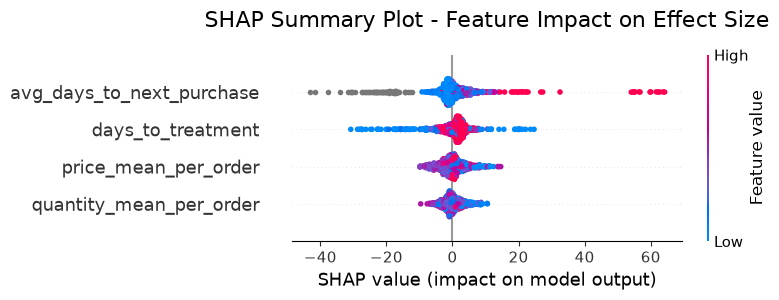

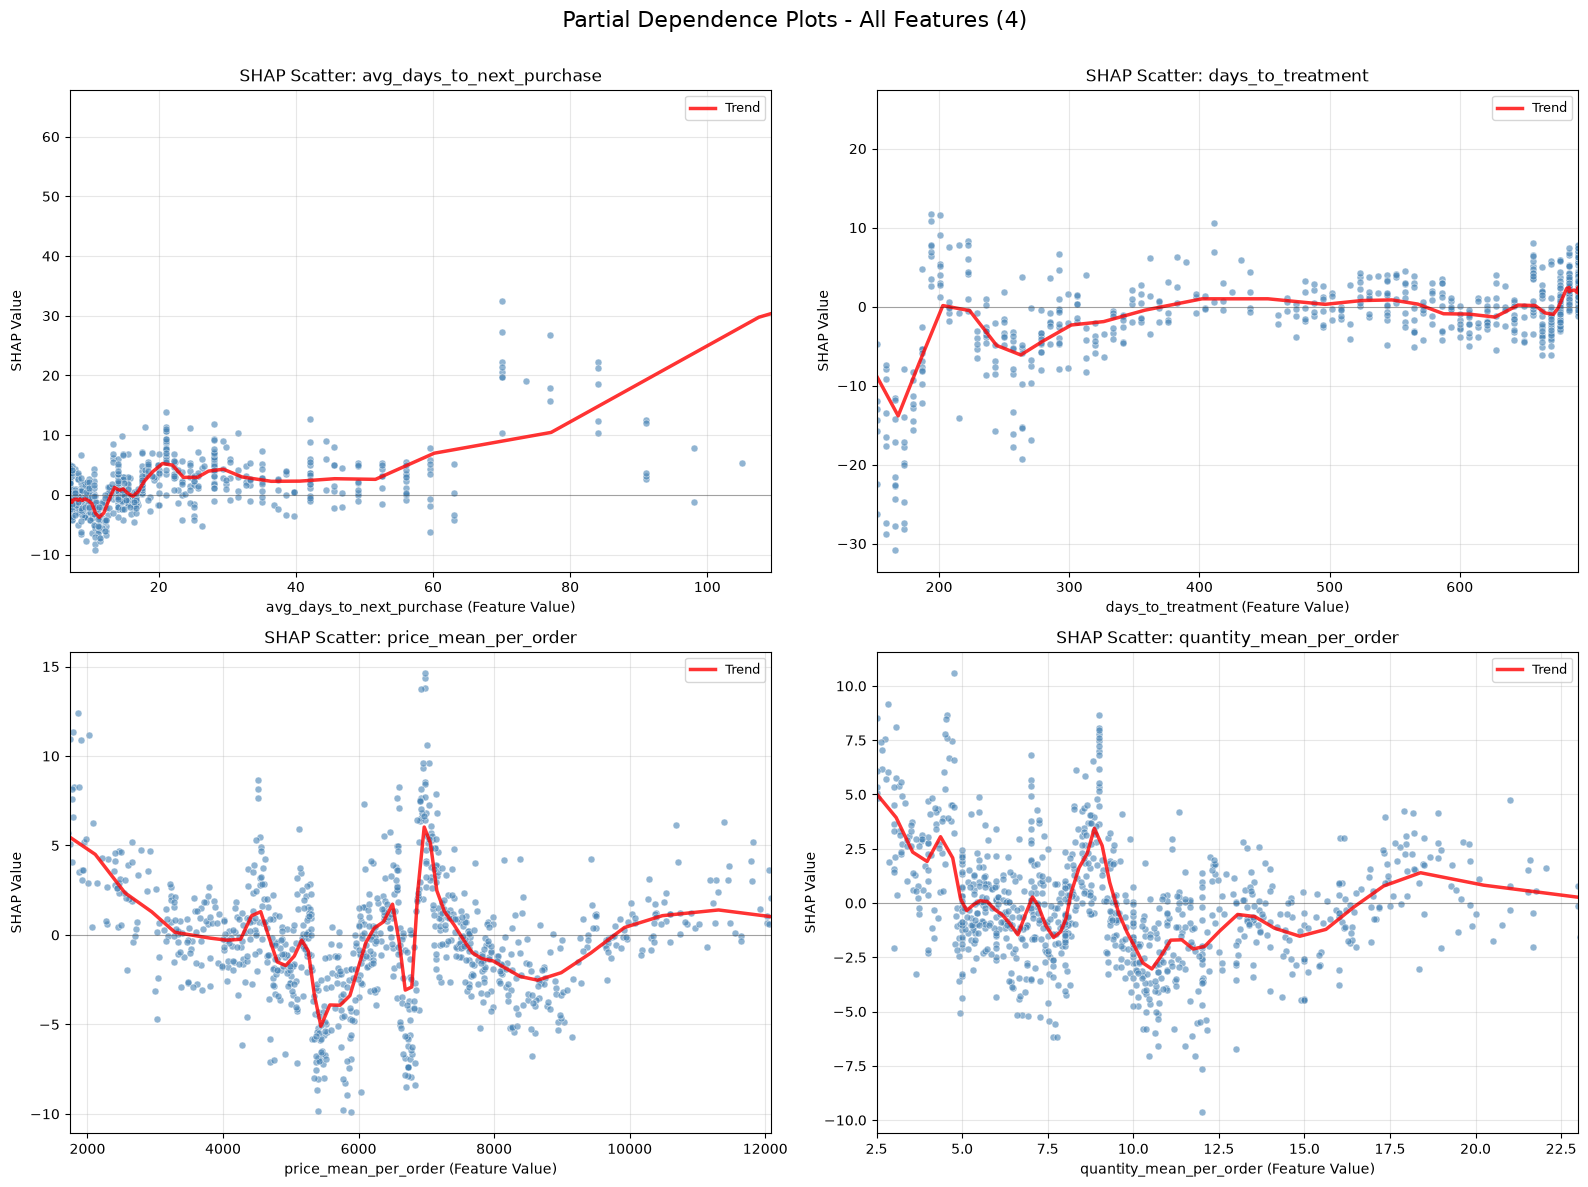

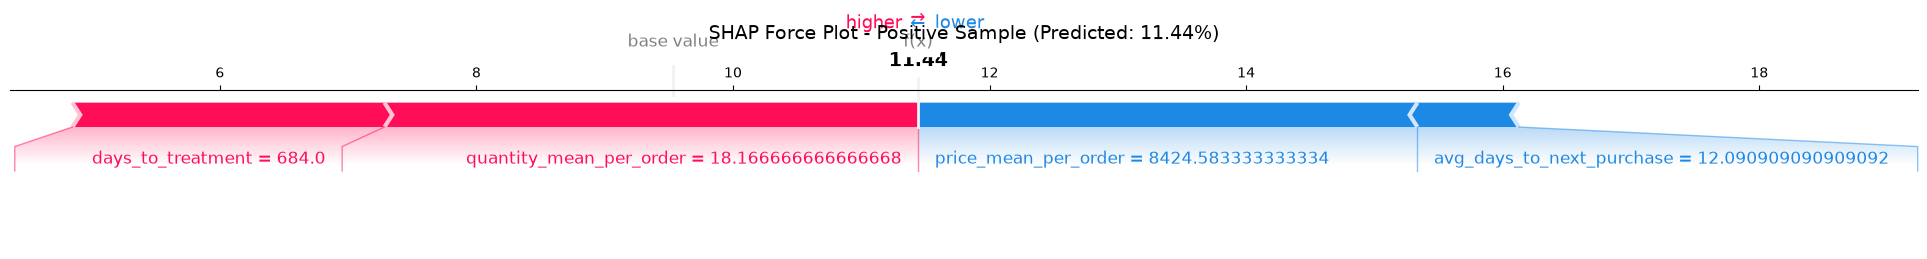

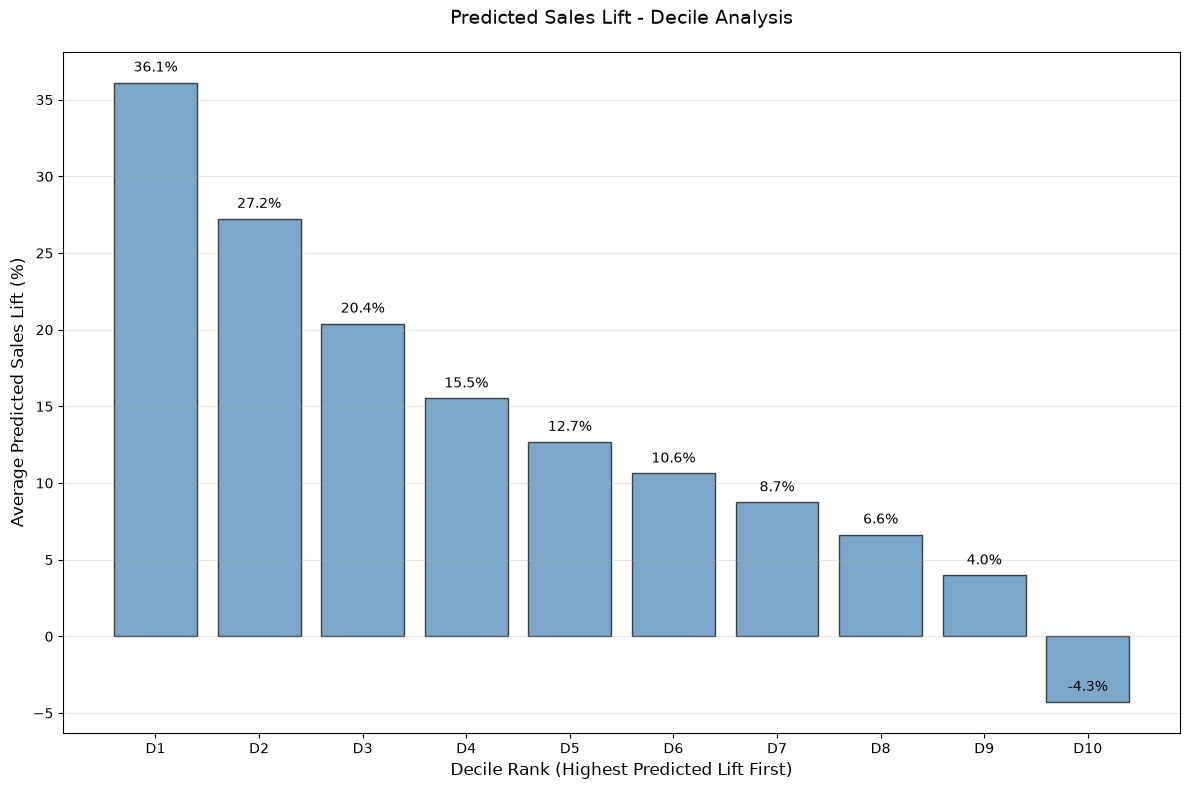

In [63]:
result = create_kpi_analysis(
    predictions_df=df_pred,
    feature_table=user_df_filled,
    outcome="quantity",
    entity_col="user_id",
    time_col="WEEK",
    treatment_start="2024-10-03",
    plot_types=["summary", "scatter", "force", "decile"],
    is_search_params=True,
    n_trials=30,
    placebo_predictions=None,
)

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[4]	valid's rmse: 75.3949
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	valid's rmse: 76.2561
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[13]	valid's rmse: 75.6546
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[4]	valid's rmse: 74.9353
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	valid's rmse: 76.3677
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	valid's rmse: 75.7769
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	valid's rmse: 75.7965
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[9]	valid's rmse: 75.2242
Training until validati

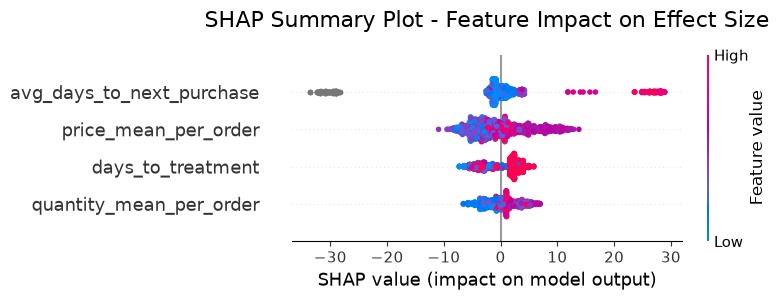

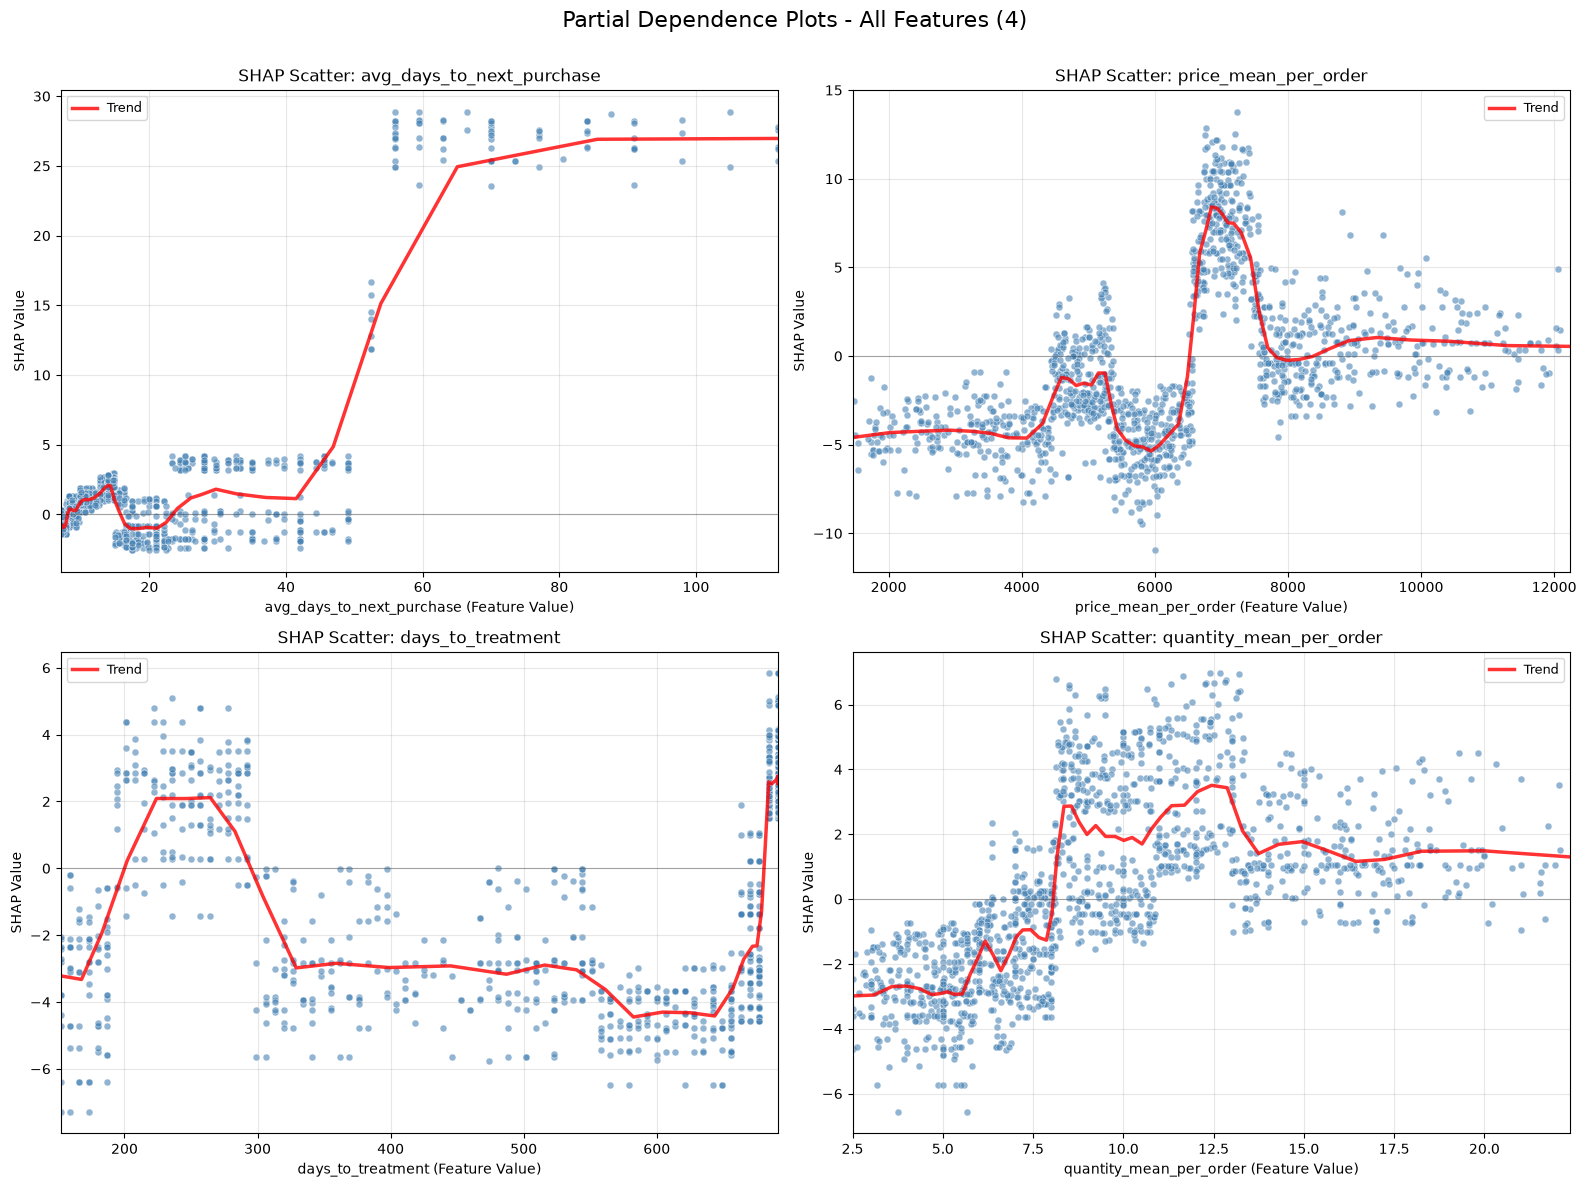

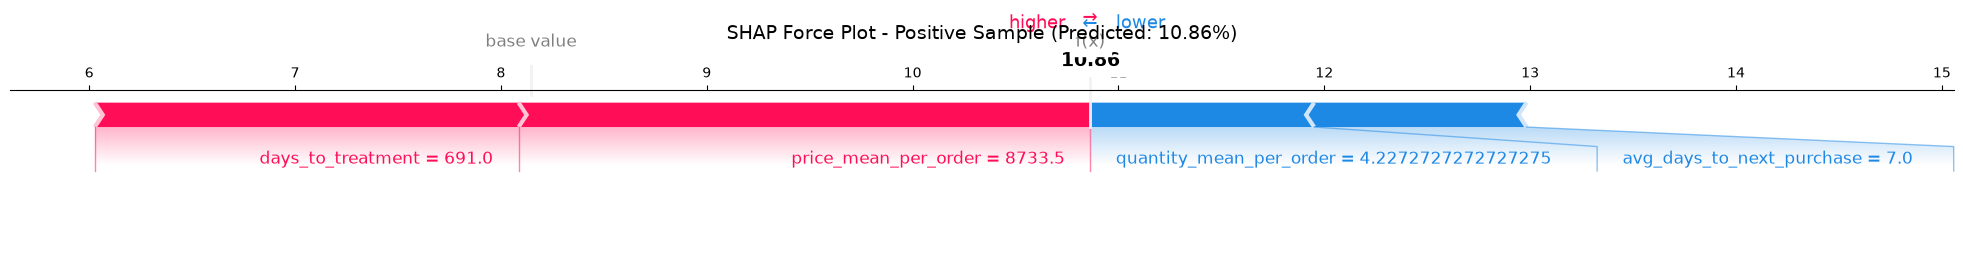

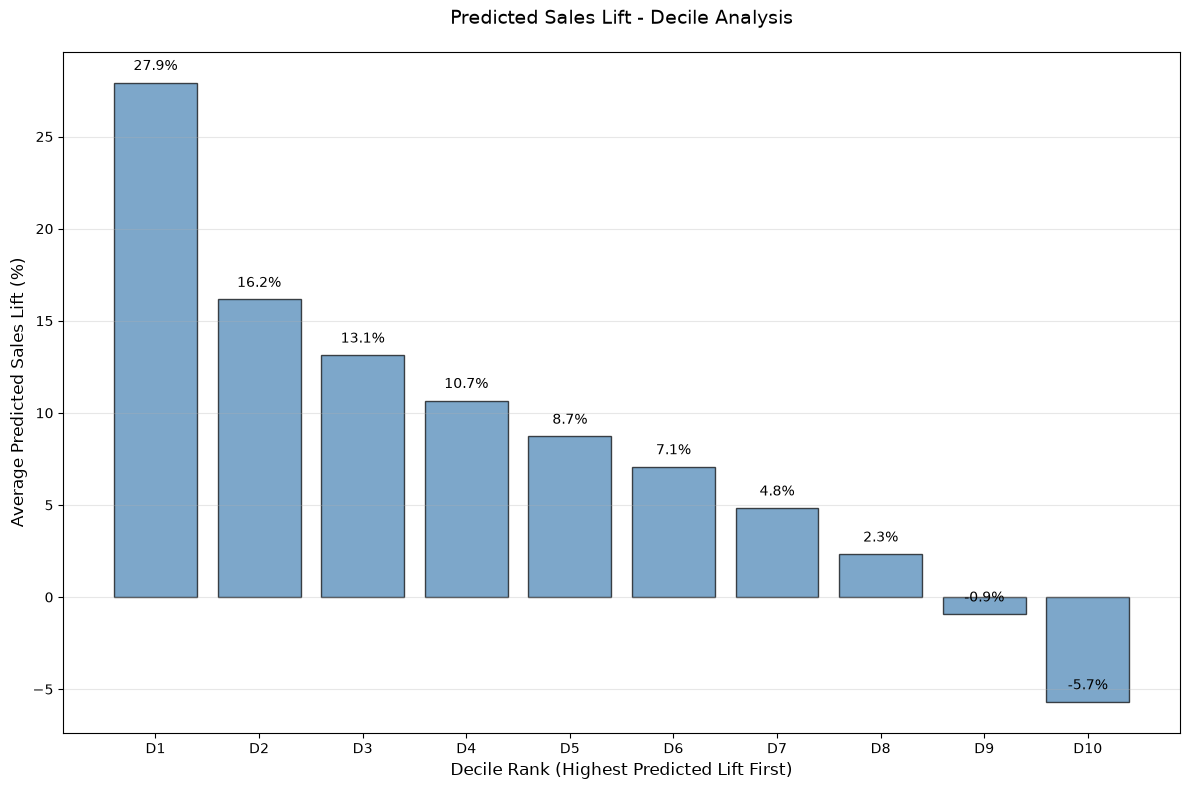

In [53]:
feature_columns = [
    "price_mean_per_order",
    "avg_days_to_next_purchase",
    "quantity_mean_per_order",
    "days_to_treatment"
]

result2 = create_kpi_analysis(
    predictions_df=df_pred,
    feature_table=user_df_filled,
    outcome="price",
    entity_col="user_id",
    time_col="WEEK",
    treatment_start="2024-10-03",
    plot_types=["summary", "scatter", "force", "decile"],
    is_search_params=True,
    n_trials=30,
    shap_sample_size=5000,
    feature_columns = feature_columns,
    placebo_predictions=None,
)

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[80]	valid's rmse: 113.75
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[48]	valid's rmse: 113.111
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[8]	valid's rmse: 116.39
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[48]	valid's rmse: 114.639
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[68]	valid's rmse: 113.949
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[22]	valid's rmse: 119.075
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid's rmse: 114.402
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid's rmse:

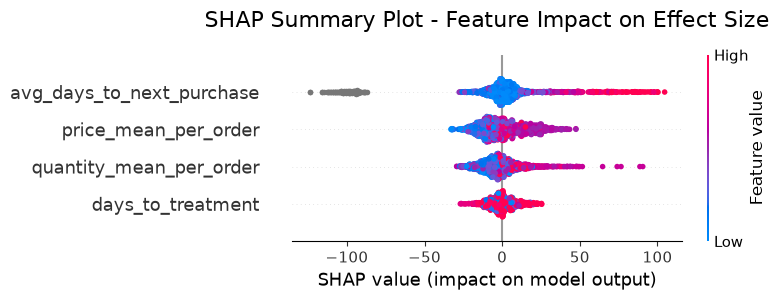

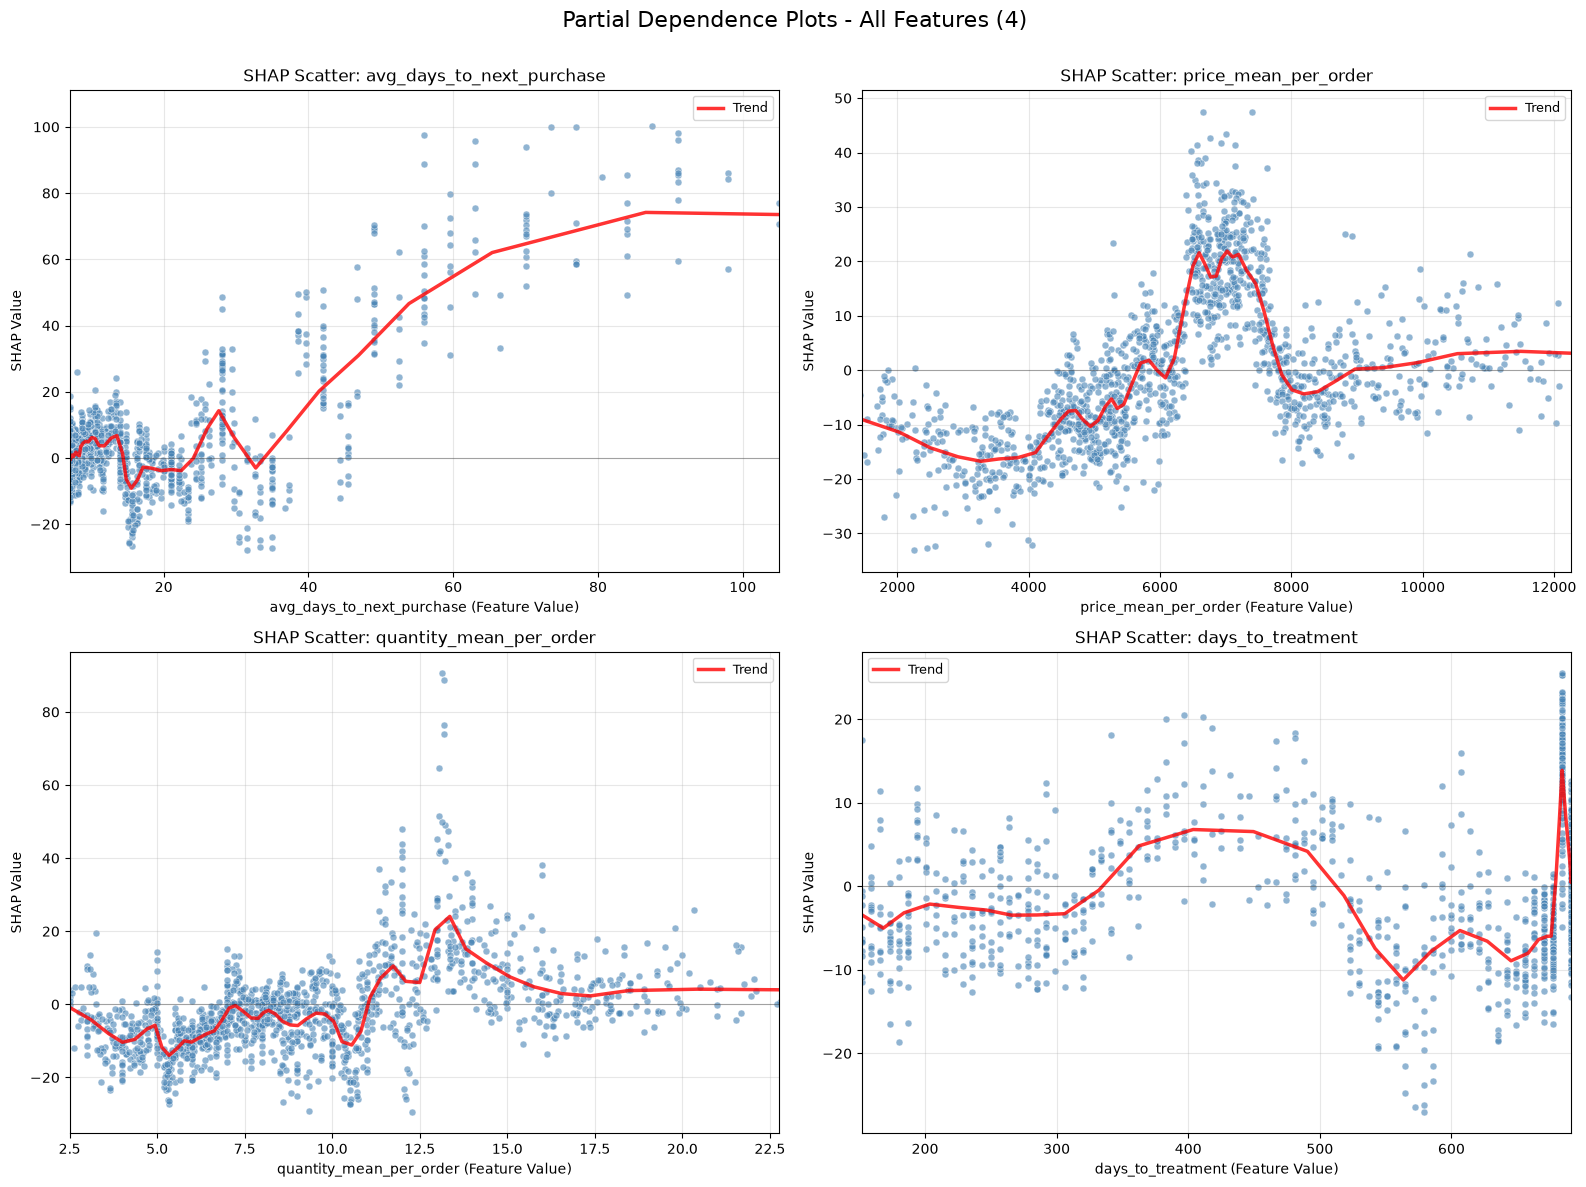

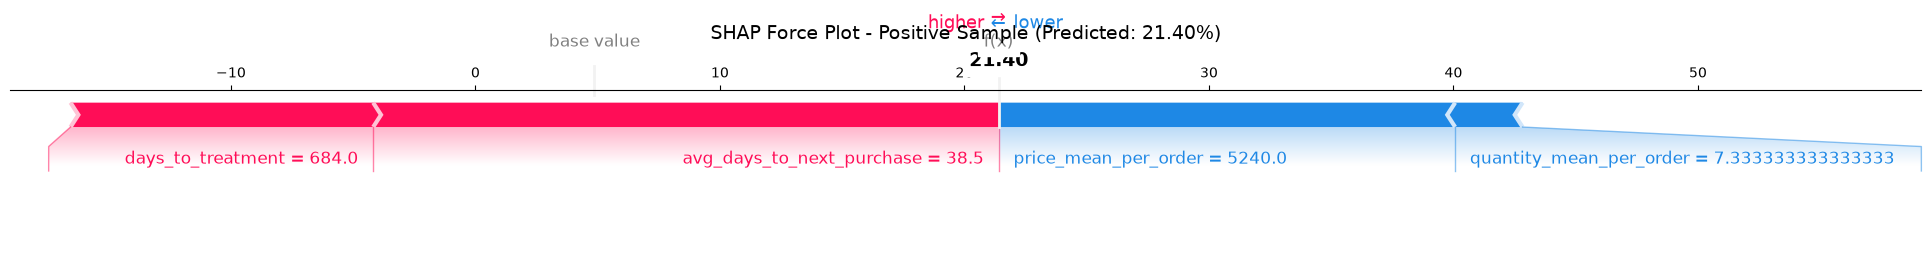

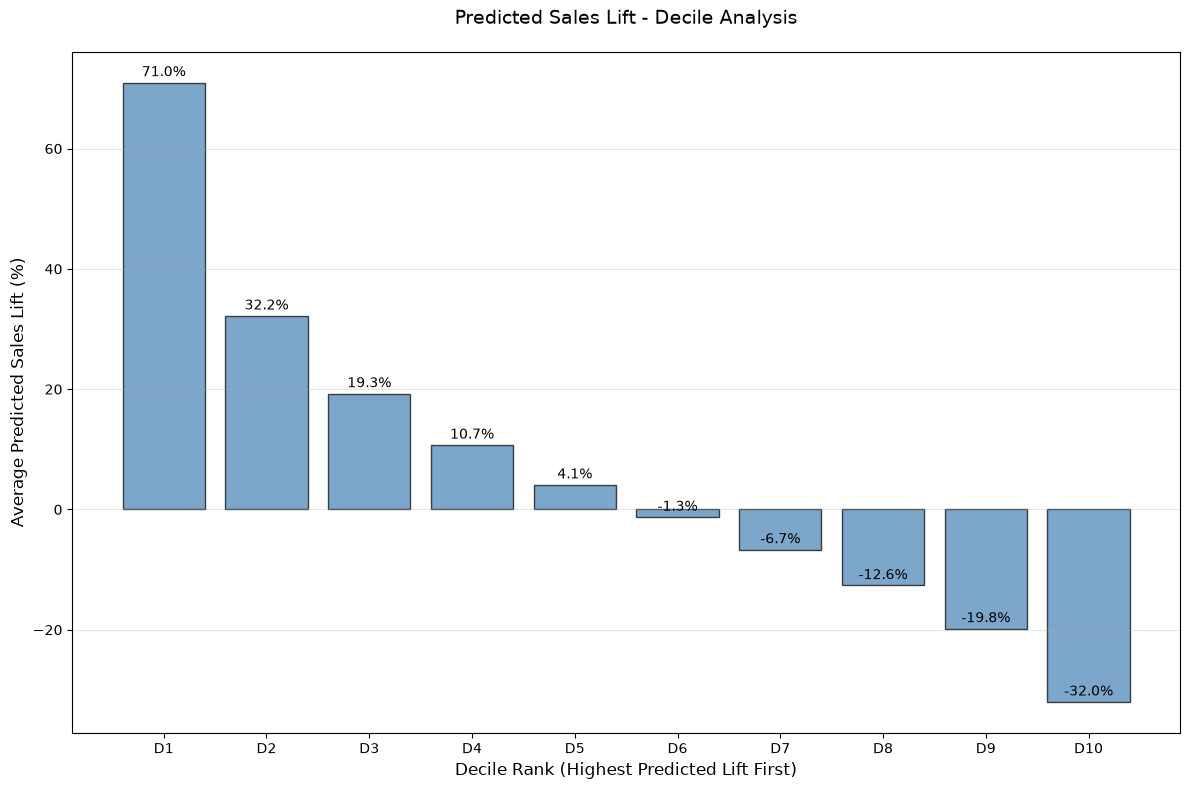

In [64]:
result3 = create_kpi_analysis(
    predictions_df=df_pred,
    feature_table=user_df_filled,
    outcome="price_per_unit",
    entity_col="user_id",
    time_col="WEEK",
    treatment_start="2024-10-03",
    plot_types=["summary", "scatter", "force", "decile"],
    is_search_params=True,
    n_trials=30,
    shap_sample_size=5000,
    feature_columns = feature_columns,
    placebo_predictions=None,
)